170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 283s 359ms/step - accuracy: 0.2771 - loss: 1.9291 - val_accuracy: 0.4303 - val_loss: 1.5289
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 284s 364ms/step - accuracy: 0.4089 - loss: 1.6191 - val_accuracy: 0.5041 - val_loss: 1.3498
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 283s 362ms/step - accuracy: 0.4676 - loss: 1.4735 - val_accuracy: 0.5474 - val_loss: 1.2420
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 284s 363ms/step - accuracy: 0.5020 - loss: 1.3887 - val_accuracy: 0.5672 - val_loss: 1.2075
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 275s 351ms/step - accuracy: 0.5264 - loss: 1.3275 - val_accuracy: 0.5863 - val_loss: 1.1401
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 322s 351ms/step - accuracy: 0.5473 - loss: 1.2735 - val_accuracy: 0.5839 - val_loss: 1.1623
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 275s 352ms/step - accuracy: 0.5650 - loss: 1.2394 - val_accuracy: 0.6255 - val_loss: 1.0286
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 274s 350ms/step - accuracy: 0.5749 -

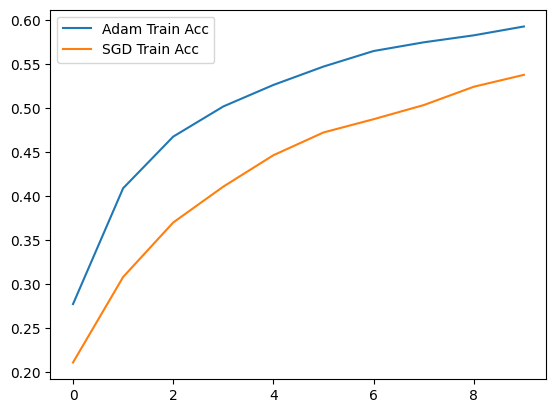

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# -----------------------------
# LOAD DATA
# -----------------------------
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

# -----------------------------
# DATA AUGMENTATION
# -----------------------------
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

datagen.fit(x_train)

# -----------------------------
# BUILD MODEL (MODIFIED)
# -----------------------------
def build_model():
    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(layers.ReLU())
    model.add(layers.Conv2D(32, (3,3), padding='same'))
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.ReLU())
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 3 (NEW - 128 filters)
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Dense
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(10, activation='softmax'))

    return model

# -----------------------------
# TRAIN WITH ADAM
# -----------------------------
model_adam = build_model()

model_adam.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = model_adam.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=10,
    validation_data=(x_test, y_test)
)

# -----------------------------
# TRAIN WITH SGD
# -----------------------------
model_sgd = build_model()

model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = model_sgd.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=10,
    validation_data=(x_test, y_test)
)

# -----------------------------
# EVALUATION
# -----------------------------
test_loss, test_acc = model_adam.evaluate(x_test, y_test)
print("Adam Test Accuracy:", test_acc)

test_loss, test_acc = model_sgd.evaluate(x_test, y_test)
print("SGD Test Accuracy:", test_acc)

# -----------------------------
# PLOT
# -----------------------------
plt.plot(history_adam.history['accuracy'], label='Adam Train Acc')
plt.plot(history_sgd.history['accuracy'], label='SGD Train Acc')
plt.legend()
plt.show()

**THEORY PART**





✅ Section 4: Conceptual Answers
1. CNN vs MLP

CNN keeps spatial structure

Uses filters for feature extraction

MLP loses pixel relationships

2. Role of filters

Detect edges, textures, shapes

Learn patterns automatically

3. Padding

Adds border pixels

Prevents size reduction

4. Pooling

Reduces dimensions

Prevents overfitting

5. Feature extraction

Process of learning patterns from images

Done by convolution layers

✅ Section 5: Implementation Answers
1. Add Dropout

✔ Done in section 2.2

2. Increase filters

✔ Done in section 2.1

3. Data augmentation

✔ Done in section 2.3

4. SGD vs Adam

✔ Done in section 2.4

✅ Section 6: Analytical Answers
1. CIFAR-10 harder than MNIST

Color images (RGB)

More complex objects

Background noise

2. Increasing filter size

Captures larger patterns

Too large → lose details

3. Removing pooling

Large feature maps

More computation

Overfitting risk

✅ Section 7: Debugging Answers
1. Overfitting

Model memorizes training data

Fix: Dropout, Augmentation

2. Normalization

Scales pixel values (0–1)

Helps faster convergence

3. Softmax

Converts outputs to probabilities

Required for multi-class classification